# Defensive AI — Multiclass Attack Type Classification (XGBoost)
## PFE 2025 — Mohamed Bouzira & Bakhti Rayane Abderaouef

**Objective:** Build a multiclass classifier to identify the **specific attack type** from honeypot network traffic using XGBoost on 244K+ balanced honeypot logs.

**Pipeline:**
1. Load & Explore Data (EDA)
2. Class Distribution Analysis
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Feature Selection
6. Label Encoding
7. Train/Test Split
8. Model Training (XGBoost multiclass)
9. Hyperparameter Tuning (RandomizedSearchCV)
10. Evaluation (Per-class metrics, Confusion Matrix, ROC curves)
11. Cross-Validation
12. Error Analysis
13. Save Model

In [1]:
# ================================================================
# Cell 1: Install Dependencies & Imports
# ================================================================
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# ================================================================
# Cell 2: Load Dataset
# ================================================================
df = pd.read_csv('honeypot_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (244085, 46)
Memory usage: 386.8 MB

Column types:
object     26
float64    19
bool        1
Name: count, dtype: int64

First 5 rows:


,bytes_sent,bytes_received,src_port,dst_port,payload_size,body_size,qos,msg_rate_per_min,req_rate_per_min,session_msg_count,session_topic_count,session_req_count,session_endpoint_count,session_path_count,session_duration_s,http_status_code,packet_count,pps,window_seconds,attack_type,is_attack,log_type,protocol,@timestamp,src_ip,dst_ip,is_internal,is_known_device,mqtt_action,client_id,topic,retain,is_known_topic,http_method,http_endpoint,user_agent,coap_method,coap_path,coap_response_code,is_known_path,eventid,username,login_success,attack_name,login_attempt,username_tried
0,96.707507,0.0,0.000000,1883.0,96.707507,0.0,0.0,15.471671,0.000000,2.17611,4.588055,0.000000,0.000000,0.000000,346.590519,0.0,0.0,0.0,0.0,topic_anomaly,True,mqtt,MQTT,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
1,0.000000,0.0,52243.150625,5683.0,0.000000,0.0,0.0,0.000000,20.657833,0.00000,0.000000,6.625292,0.000000,7.171083,43.636853,0.0,0.0,0.0,0.0,path_scan,True,coap,CoAP,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
2,0.000000,0.0,0.000000,1883.0,0.000000,0.0,0.0,6.632874,0.000000,1.55069,2.000000,0.000000,0.000000,0.000000,27.121866,0.0,0.0,0.0,0.0,wildcard_scan,True,mqtt,MQTT,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
3,0.000000,0.0,58798.000000,5683.0,0.000000,0.0,0.0,0.000000,9.000000,0.00000,0.000000,3128.000000,0.000000,2.000000,20859.190000,0.0,0.0,0.0,0.0,benign,False,coap,CoAP,2026-04-22T06:27:39.600Z,172.20.0.15,172.20.0.2,True,True,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,GET,home/motion/command,2.05 Content,True,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
4,33.000000,0.0,38778.000000,80.0,0.000000,33.0,0.0,0.000000,19.000000,0.00000,0.000000,34.769437,34.769437,0.000000,111.122224,404.0,0.0,0.0,0.0,unknown_external,True,platform,HTTP,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic


# Cell 3: Dataset Overview & Multiclass Distribution

In [3]:
# ================================================================
# Cell 3: Dataset Overview & Multiclass Distribution
# ================================================================
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)

print(f"\nTotal samples: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"\nMissing values (top 15):")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(15))

print(f"\n{'=' * 60}")
print('MULTICLASS DISTRIBUTION')
print('=' * 60)

print(f"\nNumber of classes: {df['attack_type'].nunique()}")
print(f"\nattack_type value counts:")
print(df['attack_type'].value_counts())

print(f"\n--- Per Protocol × Attack Type ---")
print(df.groupby(['log_type', 'attack_type']).size().unstack(fill_value=0))

DATASET OVERVIEW

Total samples: 244,085
Features: 46

Missing values (top 15):
Series([], dtype: int64)

MULTICLASS DISTRIBUTION

Number of classes: 15

attack_type value counts:
attack_type
benign              75600
endpoint_scan       12485
path_scan           12000
wildcard_scan       12000
unknown_external    12000
ddos                12000
topic_anomaly       12000
scan                12000
brute_force         12000
path_traversal      12000
exploit             12000
unknown             12000
unknown_client      12000
port_scan           12000
large_payload       12000
Name: count, dtype: int64

--- Per Protocol × Attack Type ---
attack_type  benign  brute_force   ddos  endpoint_scan  exploit  large_payload  path_scan  path_traversal  port_scan   scan  topic_anomaly  unknown  unknown_client  unknown_external  wildcard_scan
log_type                                                                                                                                                       

# Cell 4: EDA Visualizations

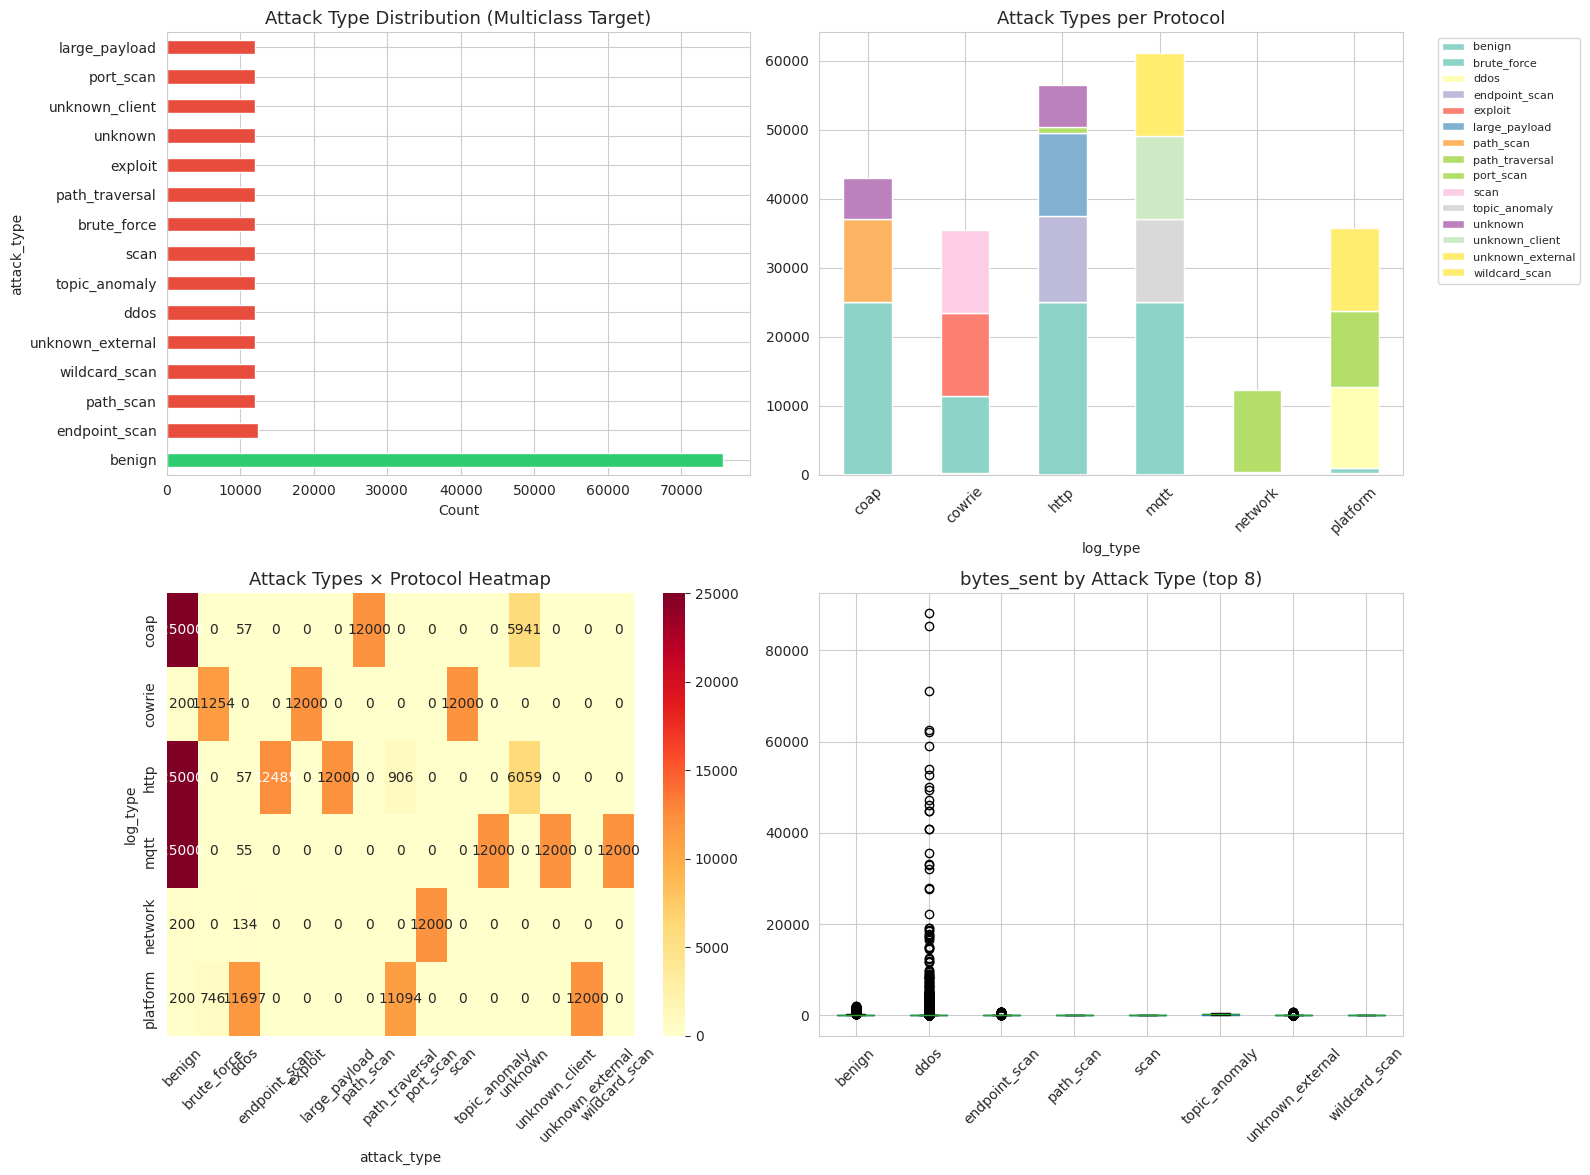

In [4]:
# ================================================================
# Cell 4: EDA Visualizations
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Attack type distribution
attack_counts = df['attack_type'].value_counts()
colors = ['#2ecc71' if c == 'benign' else '#e74c3c' for c in attack_counts.index]
attack_counts.plot.barh(ax=axes[0, 0], color=colors)
axes[0, 0].set_title('Attack Type Distribution (Multiclass Target)', fontsize=13)
axes[0, 0].set_xlabel('Count')

# 2. Protocol distribution by attack type (stacked)
ct = pd.crosstab(df['log_type'], df['attack_type'])
ct.plot.bar(ax=axes[0, 1], stacked=True, cmap='Set3')
axes[0, 1].set_title('Attack Types per Protocol', fontsize=13)
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Attack type × Protocol heatmap
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('Attack Types × Protocol Heatmap', fontsize=13)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Box plot of bytes_sent by attack type
top_types = df['attack_type'].value_counts().head(8).index
df_top = df[df['attack_type'].isin(top_types)]
df_top.boxplot(column='bytes_sent', by='attack_type', ax=axes[1, 1], rot=45)
axes[1, 1].set_title('bytes_sent by Attack Type (top 8)', fontsize=13)
axes[1, 1].set_xlabel('')
plt.suptitle('')  # remove auto-title from boxplot

plt.tight_layout()
plt.show()

# Cell 5: Correlation Analysis

Numerical features (19):
                           count      mean       std  min    25%       50%       75%        max
bytes_sent              244085.0   6177.81  28506.29  0.0   0.00      0.00    107.00  199785.00
bytes_received          244085.0      0.41     16.31  0.0   0.00      0.00      0.00    1000.00
src_port                244085.0  26043.58  24144.45  0.0   0.00  33573.61  48166.00   65534.00
dst_port                244085.0   3413.60   3191.08  0.0  80.00   1883.00   5683.00    8080.00
payload_size            244085.0     30.71     81.71  0.0   0.00      0.00      0.00    4988.00
body_size               244085.0   6139.88  28509.61  0.0   0.00      0.00      0.00  199785.00
qos                     244085.0      0.00      0.00  0.0   0.00      0.00      0.00       1.00
msg_rate_per_min        244085.0      2.05      6.42  0.0   0.00      0.00      1.00     498.00
req_rate_per_min        244085.0     80.41    336.11  0.0   0.00      3.00      9.00    3000.00
session_msg_cou

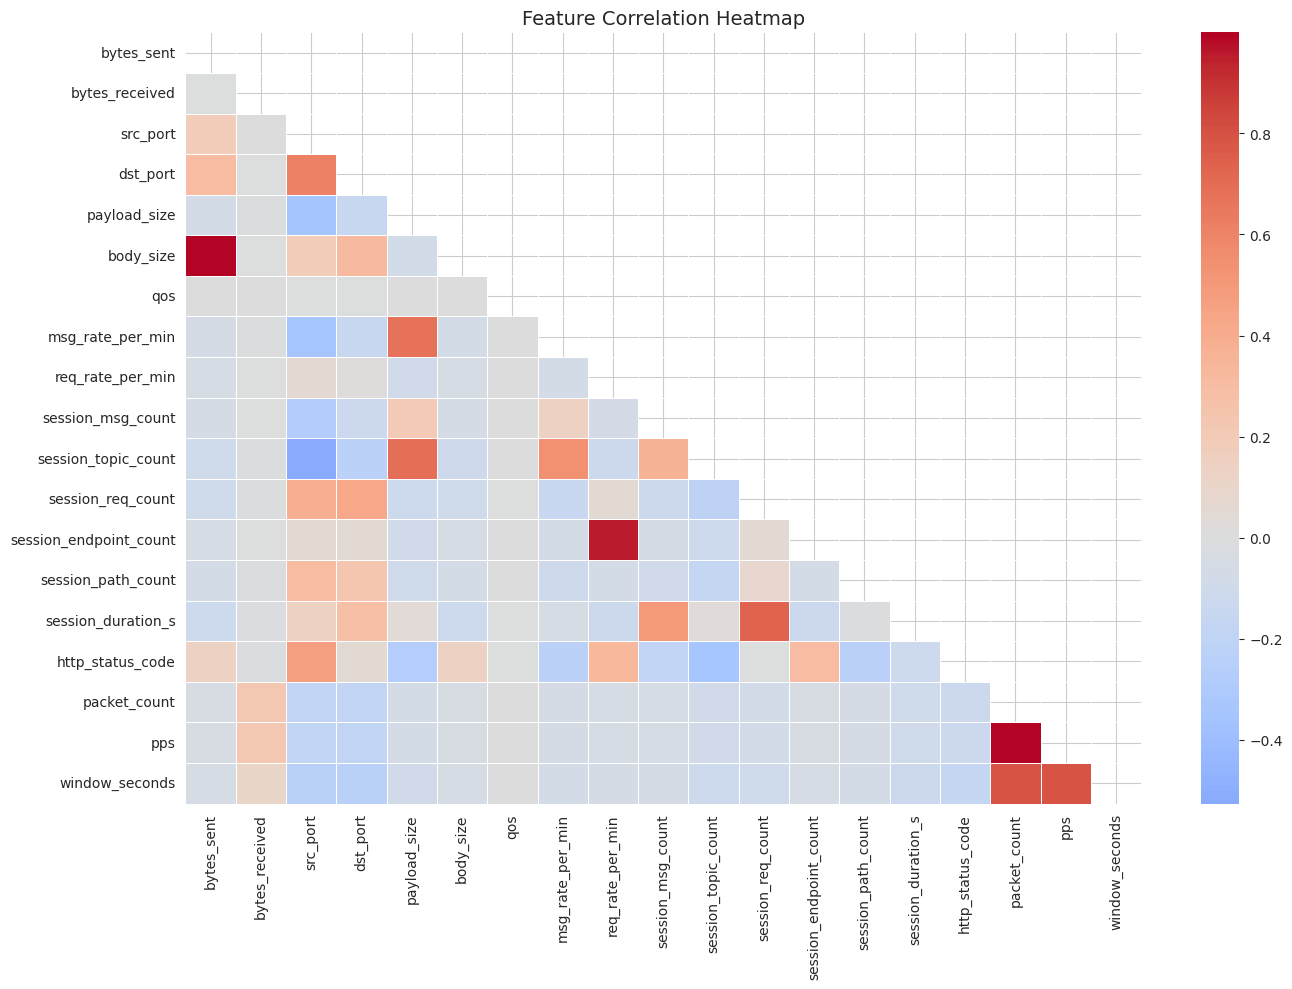

In [5]:
# ================================================================
# Cell 5: Correlation Analysis
# ================================================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features ({len(num_cols)}):")
print(df[num_cols].describe().T.round(2))

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Cell 6: Data Cleaning & Preprocessing

In [6]:
# ================================================================
# Cell 6: Data Cleaning & Preprocessing
# ================================================================
data = df.copy()

# --- Drop columns not useful for ML ---
drop_cols = [
    '@timestamp', 'src_ip', 'dst_ip', 'client_id', 'topic',
    'http_endpoint', 'user_agent', 'coap_path',
    'username', 'username_tried', 'attack_name',
    'command',
    'is_attack',  # binary target not needed for multiclass
    # Target leakage — in our honeypot ALL benign=internal+known, ALL attack=external+unknown
    'is_internal', 'is_known_device',
]
data.drop(columns=[c for c in drop_cols if c in data.columns], inplace=True)
print(f"Dropped {len(drop_cols)} identifier/leaky columns")

# --- Replace "synthetic" marker (from SMOTE) with NaN to avoid artifact leakage ---
data.replace("synthetic", np.nan, inplace=True)

# --- Fix boolean columns ---
bool_fix = ['retain', 'is_known_topic', 'is_known_path', 'login_success', 'login_attempt']
for col in bool_fix:
    if col in data.columns:
        data[col] = data[col].map({'True': 1, 'False': 0, True: 1, False: 0,
                                    'true': 1, 'false': 0}).astype('float64')
print(f"Fixed {len(bool_fix)} boolean columns")

# --- Fill NaN with 0 ---
nan_before = data.isnull().sum().sum()
data.fillna(0, inplace=True)
print(f"Filled {nan_before:,} NaN values with 0")

print(f"\nCleaned shape: {data.shape}")
print(f"Remaining NaN: {data.isnull().sum().sum()}")

Dropped 15 identifier/leaky columns
Fixed 5 boolean columns
Filled 2,230,176 NaN values with 0

Cleaned shape: (244085, 32)
Remaining NaN: 0


# Cell 7: Feature Engineering

In [7]:
# ================================================================
# Cell 7: Feature Engineering
# ================================================================
# 1. Bytes ratio
data['bytes_ratio'] = data['bytes_sent'] / (data['bytes_received'] + 1)

# 2. Total bytes
data['total_bytes'] = data['bytes_sent'] + data['bytes_received']

# 3. Port class
def port_class(port):
    if port <= 1023:
        return 0
    elif port <= 49151:
        return 1
    else:
        return 2

data['src_port_class'] = data['src_port'].apply(port_class)
data['dst_port_class'] = data['dst_port'].apply(port_class)

# 4. High rate flags
for col in ['msg_rate_per_min', 'req_rate_per_min']:
    if col in data.columns:
        threshold = data[col][data[col] > 0].quantile(0.90) if (data[col] > 0).any() else 0
        data[f'{col}_high'] = (data[col] > threshold).astype(int)

# 5. Session intensity
if 'msg_rate_per_min' in data.columns and 'session_msg_count' in data.columns:
    data['mqtt_session_intensity'] = data['msg_rate_per_min'] * data['session_msg_count']
if 'req_rate_per_min' in data.columns and 'session_req_count' in data.columns:
    data['http_session_intensity'] = data['req_rate_per_min'] * data['session_req_count']

# 6. Payload to bytes ratio
if 'payload_size' in data.columns:
    data['payload_bytes_ratio'] = data['payload_size'] / (data['total_bytes'] + 1)

# 7. Session diversity
diversity_cols = ['session_topic_count', 'session_endpoint_count', 'session_path_count']
data['session_diversity'] = data[[c for c in diversity_cols if c in data.columns]].sum(axis=1)

print(f"Shape after feature engineering: {data.shape}")

Shape after feature engineering: (244085, 42)


# Cell 8: Feature Selection & Encoding

In [8]:
# ================================================================
# Cell 8: Feature Selection & One-Hot Encoding
# ================================================================
from sklearn.feature_selection import VarianceThreshold

# --- One-hot encode categorical columns ---
cat_cols = ['log_type', 'protocol', 'mqtt_action', 'http_method',
            'coap_method', 'coap_response_code', 'eventid']
cat_cols = [c for c in cat_cols if c in data.columns]
data = pd.get_dummies(data, columns=cat_cols, drop_first=False)
print(f"After one-hot encoding: {data.shape}")

# --- Variance threshold ---
target_col = 'attack_type'
X_temp = data.drop(columns=[target_col])
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_temp)
low_var = X_temp.columns[~selector.get_support()].tolist()
if low_var:
    data.drop(columns=low_var, inplace=True)
    print(f"Dropped {len(low_var)} low-variance features")

# --- Remove highly correlated features (>0.95) ---
X_temp = data.drop(columns=[target_col])
corr_abs = X_temp.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
if high_corr:
    data.drop(columns=high_corr, inplace=True)
    print(f"Dropped {len(high_corr)} highly correlated features")

print(f"\nFinal shape: {data.shape}")

After one-hot encoding: (244085, 73)
Dropped 20 low-variance features
Dropped 16 highly correlated features

Final shape: (244085, 37)


# Cell 9: Label Encoding & Train/Test Split

In [9]:
# ================================================================
# Cell 9: Label Encoding & Train/Test Split
# ================================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
data['attack_type_enc'] = le.fit_transform(data['attack_type'])

# Label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label Encoding Mapping:')
for cls, idx in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = (data['attack_type'] == cls).sum()
    print(f'  {idx:>2}: {cls:<20s} ({count:,} samples)')

num_classes = len(le.classes_)
print(f'\nNumber of classes: {num_classes}')

# Split
X = data.drop(columns=['attack_type', 'attack_type_enc'])
y = data['attack_type_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} samples')
print(f'\nTrain class distribution:')
for idx in sorted(y_train.unique()):
    cls = le.inverse_transform([idx])[0]
    count = (y_train == idx).sum()
    print(f'  {cls:<20s}: {count:,}')

Label Encoding Mapping:
   0: benign               (75,600 samples)
   1: brute_force          (12,000 samples)
   2: ddos                 (12,000 samples)
   3: endpoint_scan        (12,485 samples)
   4: exploit              (12,000 samples)
   5: large_payload        (12,000 samples)
   6: path_scan            (12,000 samples)
   7: path_traversal       (12,000 samples)
   8: port_scan            (12,000 samples)
   9: scan                 (12,000 samples)
  10: topic_anomaly        (12,000 samples)
  11: unknown              (12,000 samples)
  12: unknown_client       (12,000 samples)
  13: unknown_external     (12,000 samples)
  14: wildcard_scan        (12,000 samples)

Number of classes: 15

Train: 195,268 samples, 36 features
Test:  48,817 samples

Train class distribution:
  benign              : 60,480
  brute_force         : 9,600
  ddos                : 9,600
  endpoint_scan       : 9,988
  exploit             : 9,600
  large_payload       : 9,600
  path_scan           : 9,

# Cell 10: XGBoost Multiclass Baseline

In [10]:
# ================================================================
# Cell 10: XGBoost Multiclass Baseline
# ================================================================
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score)
from sklearn.preprocessing import label_binarize

model_multi = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=num_classes,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
)

model_multi.fit(X_train, y_train)

y_pred = model_multi.predict(X_test)
y_prob = model_multi.predict_proba(X_test)

print('=' * 60)
print('BASELINE MULTICLASS RESULTS')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Macro AUC
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))
macro_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
print(f'Macro-Average ROC AUC: {macro_auc:.4f}')

BASELINE MULTICLASS RESULTS
                  precision    recall  f1-score   support

          benign       1.00      1.00      1.00     15120
     brute_force       0.94      0.12      0.21      2400
            ddos       1.00      1.00      1.00      2400
   endpoint_scan       1.00      1.00      1.00      2497
         exploit       0.53      0.99      0.69      2400
   large_payload       1.00      1.00      1.00      2400
       path_scan       1.00      1.00      1.00      2400
  path_traversal       0.88      0.94      0.91      2400
       port_scan       1.00      1.00      1.00      2400
            scan       1.00      0.99      1.00      2400
   topic_anomaly       1.00      1.00      1.00      2400
         unknown       1.00      1.00      1.00      2400
  unknown_client       1.00      1.00      1.00      2400
unknown_external       0.94      0.87      0.90      2400
   wildcard_scan       1.00      1.00      1.00      2400

        accuracy                          

# Cell 11: Hyperparameter Tuning (RandomizedSearchCV)

In [11]:
# ================================================================
# Cell 11: Hyperparameter Tuning
# ================================================================
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
}

xgb_tuner = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
)

random_search = RandomizedSearchCV(
    xgb_tuner,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print(f'\nBest F1-macro (CV): {random_search.best_score_:.4f}')
print(f'\nBest parameters:')
for param, val in random_search.best_params_.items():
    print(f'  {param}: {val}')

# Use best model
model_multi = random_search.best_estimator_
y_pred = model_multi.predict(X_test)
y_prob = model_multi.predict_proba(X_test)

print(f'\n{"=" * 60}')
print('TUNED MULTICLASS RESULTS')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))
macro_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
print(f'Macro-Average ROC AUC: {macro_auc:.4f}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best F1-macro (CV): 0.9153

Best parameters:
  subsample: 0.9
  n_estimators: 200
  min_child_weight: 5
  max_depth: 8
  learning_rate: 0.2
  gamma: 0.2
  colsample_bytree: 0.8

TUNED MULTICLASS RESULTS
                  precision    recall  f1-score   support

          benign       1.00      1.00      1.00     15120
     brute_force       0.94      0.12      0.21      2400
            ddos       1.00      1.00      1.00      2400
   endpoint_scan       1.00      1.00      1.00      2497
         exploit       0.53      0.99      0.69      2400
   large_payload       1.00      1.00      1.00      2400
       path_scan       1.00      1.00      1.00      2400
  path_traversal       0.91      0.94      0.92      2400
       port_scan       1.00      1.00      1.00      2400
            scan       1.00      0.99      1.00      2400
   topic_anomaly       1.00      1.00      1.00      2400
         unknown       1.00      1.00 

# Cell 12: Evaluation Visualizations

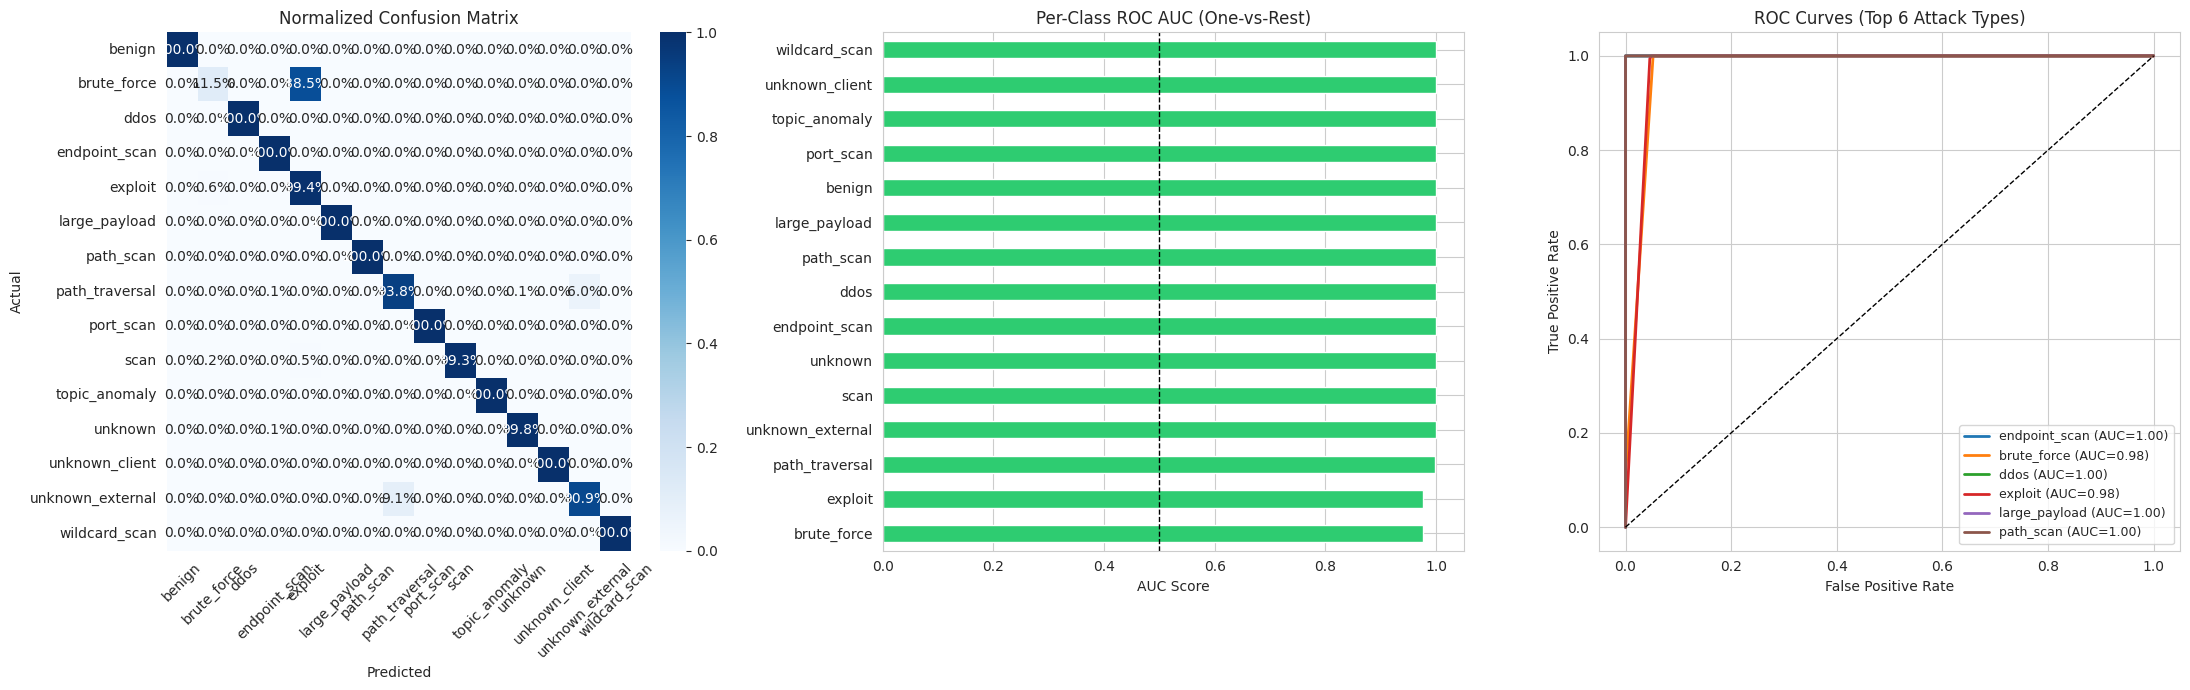

In [12]:
# ================================================================
# Cell 12: Evaluation Visualizations
# ================================================================
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Normalized Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Normalized Confusion Matrix')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# 2. Per-class ROC AUC
auc_scores = []
for i, cls in enumerate(le.classes_):
    try:
        auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    except Exception:
        auc = 0.0
    auc_scores.append(auc)

auc_series = pd.Series(auc_scores, index=le.classes_).sort_values()
colors = ['#e74c3c' if v < 0.8 else '#f39c12' if v < 0.95 else '#2ecc71' for v in auc_series.values]
auc_series.plot.barh(ax=axes[1], color=colors)
axes[1].set_title('Per-Class ROC AUC (One-vs-Rest)')
axes[1].set_xlabel('AUC Score')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1)

# 3. Per-class ROC curves (top 6 attack types by count)
attack_classes = [i for i, c in enumerate(le.classes_) if c != 'benign']
top_attack_idx = sorted(attack_classes, key=lambda i: -(y_test == i).sum())[:6]
for i in top_attack_idx:
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    axes[2].plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC={auc_scores[i]:.2f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves (Top 6 Attack Types)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Cell 13: 5-Fold Stratified Cross-Validation

In [13]:
# ================================================================
# Cell 13: 5-Fold Stratified Cross-Validation
# ================================================================
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
}

cv_results = cross_validate(
    model_multi, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

print('=' * 60)
print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS')
print('=' * 60)
print(f"{'Metric':<18} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")
print('-' * 55)
for metric in ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']:
    train_mean = cv_results[f'train_{metric}'].mean()
    test_mean = cv_results[f'test_{metric}'].mean()
    test_std = cv_results[f'test_{metric}'].std()
    print(f"{metric:<18} {train_mean:>12.4f} {test_mean:>12.4f} {test_std:>10.4f}")

gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f'\nOverfit gap: {gap:.4f}')
if gap > 0.05:
    print('Warning: Potential overfitting')
else:
    print('No significant overfitting')

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
Metric               Train Mean    Test Mean   Test Std
-------------------------------------------------------
accuracy                 0.9519       0.9486     0.0003
f1_macro                 0.9210       0.9165     0.0007
f1_weighted              0.9417       0.9384     0.0005
precision_macro          0.9592       0.9548     0.0007
recall_macro             0.9348       0.9303     0.0004

Overfit gap: 0.0033
No significant overfitting


# Cell 14: Error Analysis — Misclassification Patterns

In [14]:
# ================================================================
# Cell 14: Error Analysis — Misclassification Patterns
# ================================================================
# Which attack types get confused with each other?
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

# Find top misclassification pairs
errors = []
for true_cls in le.classes_:
    for pred_cls in le.classes_:
        if true_cls != pred_cls and cm_df.loc[true_cls, pred_cls] > 0:
            errors.append({
                'True': true_cls,
                'Predicted': pred_cls,
                'Count': cm_df.loc[true_cls, pred_cls],
                'Rate': cm_df.loc[true_cls, pred_cls] / cm_df.loc[true_cls].sum()
            })

error_df = pd.DataFrame(errors).sort_values('Count', ascending=False)
print('Top Misclassification Patterns:')
print('=' * 60)
if len(error_df) > 0:
    for _, row in error_df.head(15).iterrows():
        print(f"  {row['True']:>20s} → {row['Predicted']:<20s} "
              f"({row['Count']:>5.0f} samples, {row['Rate']:.1%} of true class)")
else:
    print('  No misclassifications found (perfect classification)!')

# Per-class accuracy
print(f'\nPer-Class Accuracy:')
print('-' * 40)
for i, cls in enumerate(le.classes_):
    total = cm[i].sum()
    correct = cm[i][i]
    acc = correct / total if total > 0 else 0
    print(f'  {cls:<20s}: {acc:.1%} ({correct}/{total})')

Top Misclassification Patterns:
           brute_force → exploit              ( 2123 samples, 88.5% of true class)
      unknown_external → path_traversal       (  218 samples, 9.1% of true class)
        path_traversal → unknown_external     (  143 samples, 6.0% of true class)
               exploit → brute_force          (   14 samples, 0.6% of true class)
                  scan → exploit              (   11 samples, 0.5% of true class)
                  scan → brute_force          (    5 samples, 0.2% of true class)
               unknown → endpoint_scan        (    3 samples, 0.1% of true class)
        path_traversal → endpoint_scan        (    3 samples, 0.1% of true class)
        path_traversal → unknown              (    2 samples, 0.1% of true class)
                  ddos → unknown_external     (    1 samples, 0.0% of true class)
                benign → endpoint_scan        (    1 samples, 0.0% of true class)
               unknown → benign               (    1 samples, 0.0

# Cell 15: Feature Importance

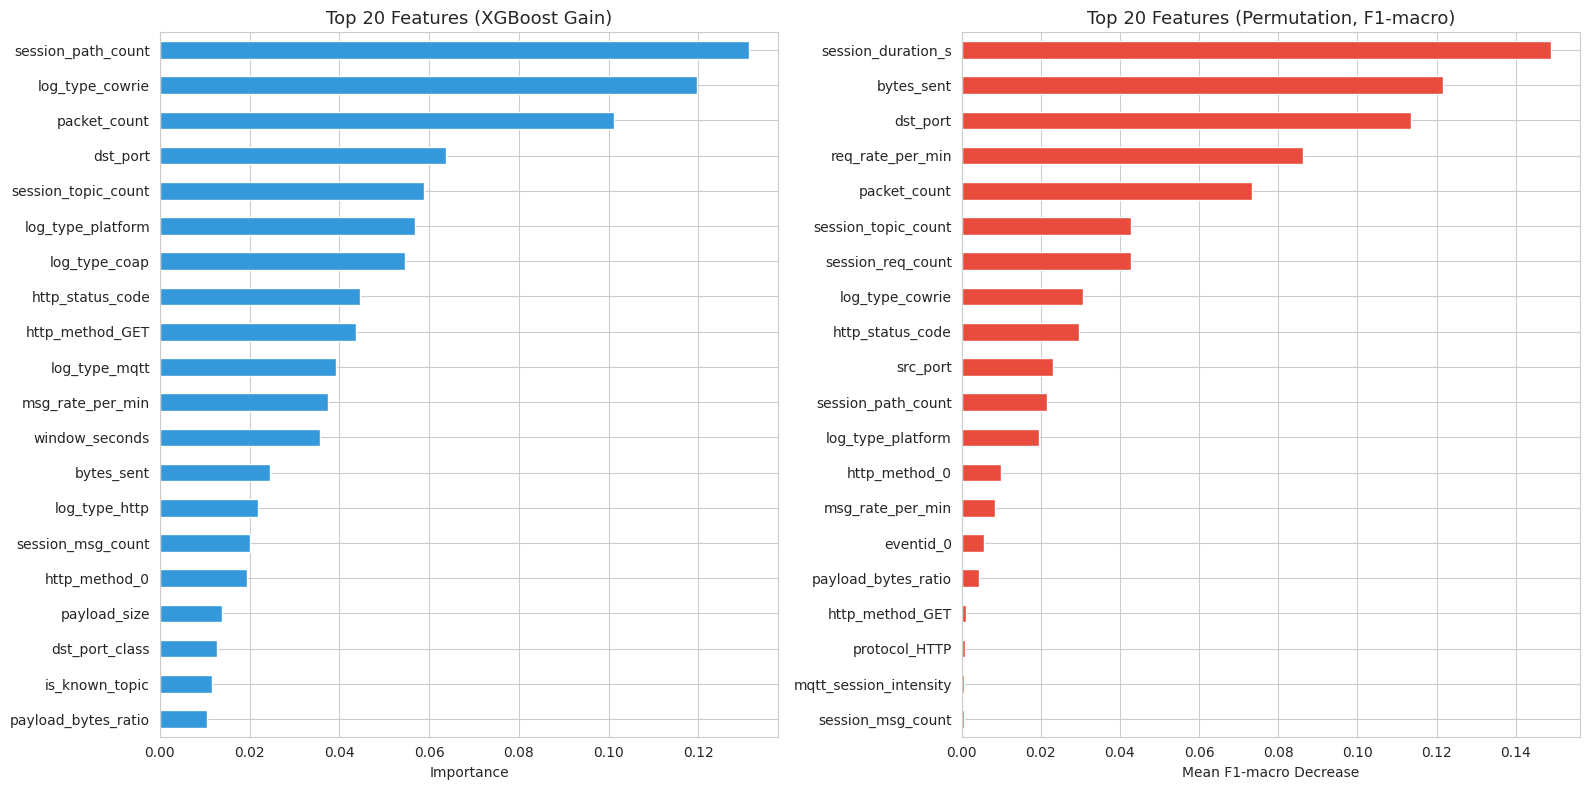

In [15]:
# ================================================================
# Cell 15: Feature Importance
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. XGBoost gain importance
importance = model_multi.feature_importances_
feat_imp = pd.Series(importance, index=X_train.columns).nlargest(20)
feat_imp.sort_values().plot.barh(ax=axes[0], color='#3498db')
axes[0].set_title('Top 20 Features (XGBoost Gain)', fontsize=13)
axes[0].set_xlabel('Importance')

# 2. Permutation importance
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    model_multi, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1, scoring='f1_macro'
)
perm_series = pd.Series(perm_imp.importances_mean, index=X_test.columns).nlargest(20)
perm_series.sort_values().plot.barh(ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 Features (Permutation, F1-macro)', fontsize=13)
axes[1].set_xlabel('Mean F1-macro Decrease')

plt.tight_layout()
plt.show()

# Cell 16: Save Model

In [16]:
# ================================================================
# Cell 16: Save Model
# ================================================================
import pickle
import json as json_lib

with open('xgboost_multiclass.pkl', 'wb') as f:
    pickle.dump(model_multi, f)

with open('label_encoder_multiclass.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save metadata
metadata = {
    'model': 'XGBoost Multiclass Classifier',
    'num_classes': num_classes,
    'class_names': list(le.classes_),
    'features': list(X_train.columns),
    'n_features': X_train.shape[1],
    'train_samples': X_train.shape[0],
    'test_samples': X_test.shape[0],
    'best_params': random_search.best_params_,
    'cv_f1_macro_mean': float(cv_results['test_f1_macro'].mean()),
    'cv_f1_macro_std': float(cv_results['test_f1_macro'].std()),
    'test_macro_auc': float(macro_auc),
}

with open('xgboost_multiclass_metadata.json', 'w') as f:
    json_lib.dump(metadata, f, indent=2)

print('Saved: xgboost_multiclass.pkl')
print('Saved: label_encoder_multiclass.pkl')
print('Saved: xgboost_multiclass_metadata.json')
print(f'\nModel summary:')
for k, v in metadata.items():
    if k not in ('features', 'class_names'):
        print(f'  {k}: {v}')

Saved: xgboost_multiclass.pkl
Saved: label_encoder_multiclass.pkl
Saved: xgboost_multiclass_metadata.json

Model summary:
  model: XGBoost Multiclass Classifier
  num_classes: 15
  n_features: 36
  train_samples: 195268
  test_samples: 48817
  best_params: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.8}
  cv_f1_macro_mean: 0.9165463039130859
  cv_f1_macro_std: 0.0007229113777667477
  test_macro_auc: 0.9967617624809783
